In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
import pandas as pd

df = pd.read_csv("ML_input_VST.csv")
df = df.set_index(df.columns[0])
df.index.name = None

df_t = df.T
df_t.index.name = "gene"

df_t.to_csv("transposed_ml_vst.csv")

In [32]:

df = pd.read_csv("/content/transposed_ml_vst.csv")
df = df.set_index(df.columns[0])
df = df.T


In [33]:
y = np.array([0]*18 + [1]*18)
X = df.copy()
X = X.drop(columns=["Y"], errors="ignore")
assert X.shape[0] == len(y), "Mismatch between samples and labels"


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [35]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

In [37]:
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=500
)

lasso_params = {"C": np.logspace(-3, 1, 10)}

lasso_grid = GridSearchCV(
    lasso, lasso_params,
    cv=5,
    scoring="f1"
)
lasso_grid.fit(X_train_scaled, y_train)

lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test_scaled)


In [45]:
best_params_df = pd.DataFrame([lasso_grid.best_params_])
best_params_df["best_f1_score"] = lasso_grid.best_score_




          C  best_f1_score
0  3.593814           0.66


In [47]:
lasso_grid_df = pd.DataFrame(lasso_grid.cv_results_)
lasso_grid_df.to_csv("lasso_grid_results.csv", index=False)

In [38]:
def evaluate(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Sensitivity:", tp / (tp + fn))
    print("Specificity:", tn / (tn + fp))

evaluate(y_test, lasso_pred, "LASSO")


LASSO
Accuracy: 0.625
F1 Score: 0.6666666666666666
Sensitivity: 0.75
Specificity: 0.5


In [39]:
genes = X.columns


lasso_genes = pd.Series(
    np.abs(lasso_best.coef_[0]),
    index=genes
)
lasso_genes = lasso_genes[lasso_genes > 0].sort_values(ascending=False).head(20)

/tmp/ipykernel_1478/213158248.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


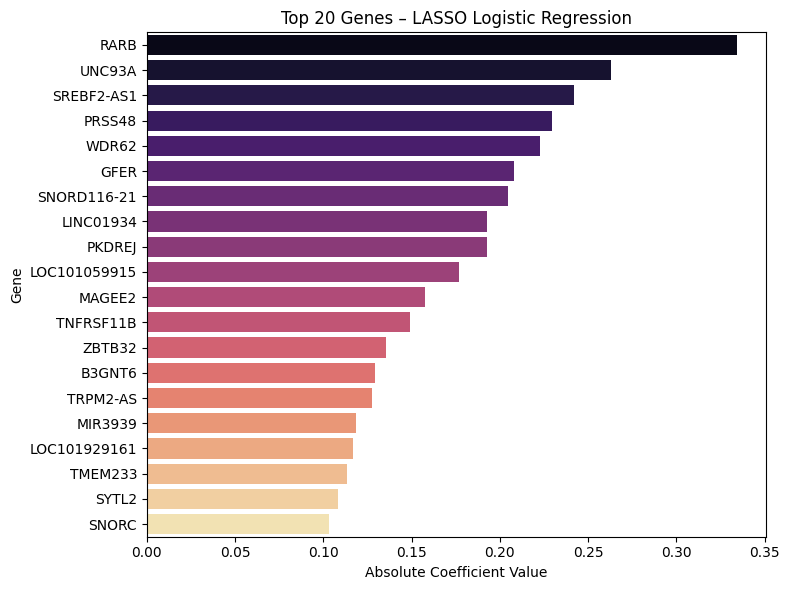

In [40]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=lasso_genes.values,
    y=lasso_genes.index,
    palette="magma"
)
plt.title("Top 20 Genes – LASSO Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


In [41]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

lasso_probs = lasso_best.predict_proba(X_test_scaled)[:, 1]
lasso_fpr, lasso_tpr, _ = roc_curve(y_test, lasso_probs)
lasso_auc = auc(lasso_fpr, lasso_tpr)




In [42]:
print("ROC-AUC Scores:")
print(f"LASSO AUC: {lasso_auc:.3f}")

ROC-AUC Scores:
LASSO AUC: 0.562


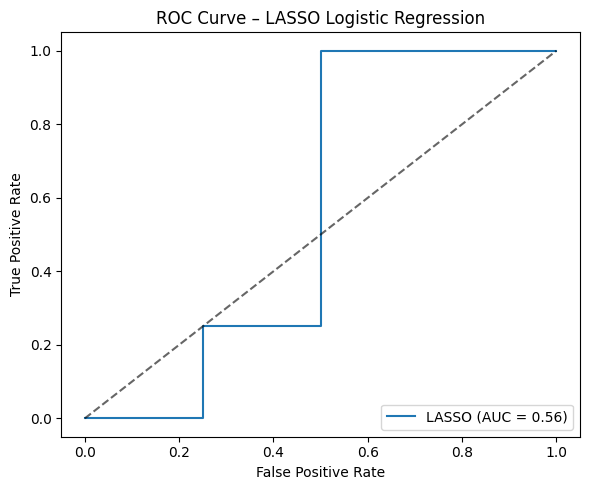

LASSO ROC-AUC: 0.562


In [43]:
lasso_probs = lasso_best.predict_proba(X_test_scaled)[:, 1]
lasso_fpr, lasso_tpr, _ = roc_curve(y_test, lasso_probs)
lasso_auc = auc(lasso_fpr, lasso_tpr)

plt.figure(figsize=(6, 5))
plt.plot(lasso_fpr, lasso_tpr, label=f"LASSO (AUC = {lasso_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LASSO Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"LASSO ROC-AUC: {lasso_auc:.3f}")
